# Analista de Experiencia del Cliente — 29/06/2026

## Pregunta de negocio

**¿Cuál es la puntuación media dada por los usuarios a los alojamientos turísticos y qué porcentaje de alojamientos tienen una evaluación general superior a 80 en cada ciudad?**

Este notebook corresponde al perfil de **Analista de Experiencia del Cliente** del Sprint 1. El análisis utiliza el dataset final después de los procesos de Data Cleaning, Data Transformation y Data Reduction.

## Variables principales

- `apartment_id`: identificador único del alojamiento.
- `city`: ciudad del alojamiento.
- `review_scores_rating`: valoración general en escala de 0 a 100.
- `rating_above_80`: indica si la valoración general es superior a 80.

Para el análisis complementario del **KPI 4** también se utilizan:

- `review_scores_accuracy`: precisión.
- `review_scores_cleanliness`: limpieza.
- `review_scores_checkin`: check-in.
- `review_scores_communication`: comunicación.
- `review_scores_location`: ubicación.

## Objetivos del análisis

- Calcular el **KPI 3: índice de satisfacción general**.
- Calcular la puntuación media por ciudad.
- Calcular el porcentaje de alojamientos con puntuación superior a 80 por ciudad.
- Mostrar el número de alojamientos evaluados y la cobertura de valoraciones.
- Analizar la distribución de las puntuaciones entre ciudades.
- Calcular el **KPI 4: componente con mayor satisfacción promedio**.
- Comprobar si las diferencias observadas entre ciudades son estadísticamente significativas.
- Generar conclusiones y recomendaciones para el área de experiencia del cliente.

## Criterio para los valores ausentes

Los alojamientos sin puntuación no se consideran como puntuaciones bajas. Se excluyen únicamente del denominador de las métricas que requieren una valoración válida.

## Estructura del análisis

1. Carga y validación del dataset.
2. Tratamiento de valores nulos.
3. Cálculo de los KPI principales.
4. Comparación visual por ciudad.
5. Análisis complementario de los componentes de satisfacción.
6. Contraste estadístico.
7. Conclusiones y recomendaciones.


## 1. Librerías y sistema visual StaySpain

Se utiliza una combinación de **Pandas, Matplotlib, Seaborn y SciPy**.  
La paleta mantiene la identidad visual compartida por el equipo.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import FancyBboxPatch
from scipy.stats import chi2_contingency, kruskal

sns.set_theme(style="whitegrid", context="notebook")

NAVY, ACERO, TEAL, AQUA = "#173453", "#2E6B96", "#2F8F8F", "#5FBDB0"
AMARILLO, AMBAR = "#F6C445", "#E08A3C"
CIELO, TERRACOTA = "#6FA8C7", "#C25B4E"
TINTA, TINTA_SUAVE, REJILLA, BLANCO = "#0B0B0B", "#52514E", "#E1E0D9", "#FFFFFF"

COLOR_CIUDAD = {
    "barcelona": NAVY, "girona": ACERO, "madrid": TEAL,
    "malaga": AQUA, "mallorca": AMARILLO, "menorca": AMBAR,
    "sevilla": CIELO, "valencia": TERRACOTA,
}

plt.rcParams.update({
    "figure.figsize": (10, 5.5), "figure.dpi": 115,
    "axes.titlesize": 15, "axes.titleweight": "bold",
    "axes.titlecolor": TINTA, "axes.labelcolor": TINTA_SUAVE,
    "axes.edgecolor": "#898781", "axes.spines.top": False,
    "axes.spines.right": False, "xtick.color": TINTA_SUAVE,
    "ytick.color": TINTA_SUAVE, "grid.color": REJILLA,
    "figure.facecolor": BLANCO, "axes.facecolor": BLANCO,
})


def color_ciudad(ciudad):
    """Devuelve el color corporativo asociado a una ciudad."""
    return COLOR_CIUDAD.get(str(ciudad).lower(), ACERO)


def tabla_grafica(
    dataframe, titulo, formatos=None, destacar_max=None,
    destacar_min=None, ancho=None
):
    """Renderiza una tabla compacta, limpia y estable en GitHub."""
    datos = dataframe.copy()

    if formatos:
        for columna, formato in formatos.items():
            if columna in datos.columns:
                datos[columna] = datos[columna].map(
                    lambda valor: formato.format(valor) if pd.notna(valor) else "—"
                )

    filas, columnas = datos.shape
    ancho = ancho or max(7.5, columnas * 1.7)
    alto = max(2.3, 0.43 * filas + 1.35)

    fig, ax = plt.subplots(figsize=(ancho, alto))
    ax.axis("off")

    tabla = ax.table(
        cellText=datos.values,
        colLabels=datos.columns,
        cellLoc="center",
        colLoc="center",
        bbox=[0.02, 0.02, 0.96, 0.82],
    )
    tabla.auto_set_font_size(False)
    tabla.set_fontsize(9.5)

    for (fila, columna), celda in tabla.get_celld().items():
        celda.set_edgecolor(BLANCO)
        celda.set_linewidth(1.4)

        if fila == 0:
            celda.set_facecolor(NAVY)
            celda.set_text_props(color=BLANCO, weight="bold")
        else:
            celda.set_facecolor("#EEF4F6" if fila % 2 else "#F8FAFA")
            celda.set_text_props(color=TINTA)
            if columna == 0:
                celda.get_text().set_ha("left")

    def resaltar(columna, indice, color):
        if columna in dataframe.columns and indice is not None:
            fila_tabla = list(dataframe.index).index(indice) + 1
            col_tabla = list(dataframe.columns).index(columna)
            tabla[(fila_tabla, col_tabla)].set_facecolor(color)
            tabla[(fila_tabla, col_tabla)].set_text_props(weight="bold")

    if destacar_max:
        for columna in destacar_max:
            resaltar(columna, dataframe[columna].astype(float).idxmax(), "#D9EEE8")

    if destacar_min:
        for columna in destacar_min:
            resaltar(columna, dataframe[columna].astype(float).idxmin(), "#F7E3DF")

    ax.set_title(titulo, fontsize=15, fontweight="bold", color=TINTA, pad=12)
    plt.tight_layout()
    plt.show()


def etiquetas_barras(ax, sufijo="", decimales=2, desplazamiento=0.2):
    """Añade etiquetas numéricas al final de barras horizontales."""
    for barra in ax.patches:
        valor = barra.get_width()
        ax.text(
            valor + desplazamiento,
            barra.get_y() + barra.get_height() / 2,
            f"{valor:.{decimales}f}{sufijo}",
            va="center", fontsize=9.5, color=TINTA_SUAVE,
        )


def tarjetas_kpi(tarjetas, titulo):
    """Muestra una fila compacta de tarjetas KPI."""
    fig, axes = plt.subplots(1, len(tarjetas), figsize=(13, 3))

    for ax, (etiqueta, valor, color) in zip(axes, tarjetas):
        ax.set(xlim=(0, 1), ylim=(0, 1))
        ax.axis("off")
        ax.add_patch(FancyBboxPatch(
            (0.04, 0.12), 0.92, 0.76,
            boxstyle="round,pad=0.02,rounding_size=0.05",
            facecolor=color, edgecolor=color,
        ))
        ax.text(
            0.5, 0.58, valor, ha="center", va="center",
            fontsize=20, fontweight="bold", color=BLANCO,
        )
        ax.text(
            0.5, 0.30, etiqueta, ha="center", va="center",
            fontsize=9.5, color=BLANCO,
        )

    fig.suptitle(titulo, fontsize=16, fontweight="bold", color=TINTA)
    plt.tight_layout()
    plt.show()


## 2. Localización y carga del dataset

In [2]:
def encontrar_raiz_proyecto(nombre="Equip_34"):
    """Localiza la raíz del proyecto desde cualquier subcarpeta."""
    actual = Path.cwd()

    for carpeta in [actual, *actual.parents]:
        if carpeta.name == nombre:
            return carpeta

    raise FileNotFoundError(
        f"No se encontró la carpeta '{nombre}' desde {actual}."
    )


raiz_proyecto = encontrar_raiz_proyecto()
ruta_datos = raiz_proyecto / "Data" / "clean_dataset_29_06_2026.csv"

df = pd.read_csv(ruta_datos)
print(f"Dataset cargado: {df.shape[0]:,} filas y {df.shape[1]} columnas")


Dataset cargado: 6,733 filas y 18 columnas


## 3. Validación de las variables necesarias

In [3]:
columnas_principales = [
    "apartment_id", "city", "review_scores_rating", "rating_above_80"
]

columnas_satisfaccion = [
    "review_scores_accuracy", "review_scores_cleanliness",
    "review_scores_checkin", "review_scores_communication",
    "review_scores_location",
]

columnas_necesarias = columnas_principales + columnas_satisfaccion
columnas_faltantes = [
    columna for columna in columnas_necesarias if columna not in df.columns
]

if columnas_faltantes:
    raise ValueError(f"Faltan columnas necesarias: {columnas_faltantes}")

if df["apartment_id"].duplicated().any():
    raise ValueError("El dataset contiene apartment_id duplicados.")

rating_valido = (
    df["review_scores_rating"].isna()
    | df["review_scores_rating"].between(0, 100)
)

if not rating_valido.all():
    raise ValueError("review_scores_rating contiene valores fuera de 0–100.")

for columna in columnas_satisfaccion:
    valores_validos = df[columna].isna() | df[columna].between(0, 10)
    if not valores_validos.all():
        raise ValueError(f"{columna} contiene valores fuera de 0–10.")

df["rating_above_80"] = df["rating_above_80"].astype("boolean")
coherencia = (
    (df["review_scores_rating"].isna() & df["rating_above_80"].isna())
    | (
        df["review_scores_rating"].notna()
        & (
            df["rating_above_80"]
            == (df["review_scores_rating"] > 80)
        )
    )
)

if not coherencia.all():
    raise ValueError("rating_above_80 no coincide con review_scores_rating.")

print("Validación completada: columnas, duplicados, escalas y coherencia correctas.")


Validación completada: columnas, duplicados, escalas y coherencia correctas.


## 4. Valores nulos y base analítica

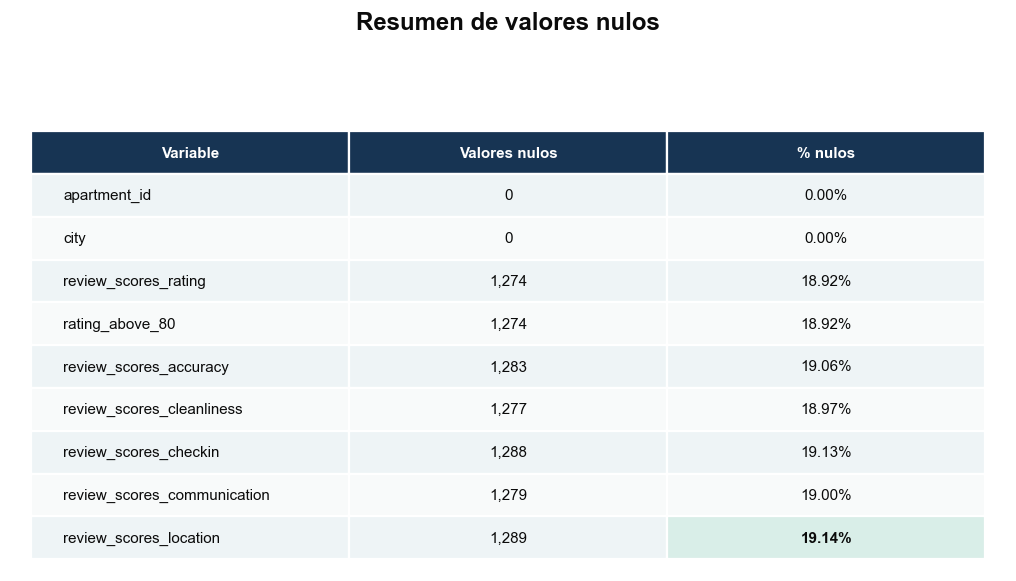

In [4]:
resumen_nulos = (
    df[columnas_necesarias]
    .isna()
    .sum()
    .rename("Valores nulos")
    .reset_index()
    .rename(columns={"index": "Variable"})
)

resumen_nulos["% nulos"] = (
    resumen_nulos["Valores nulos"] / len(df) * 100
).round(2)

tabla_grafica(
    resumen_nulos,
    "Resumen de valores nulos",
    formatos={"Valores nulos": "{:,.0f}", "% nulos": "{:.2f}%"},
    destacar_max=["% nulos"],
    ancho=9,
)


In [5]:
df_customer = df.dropna(
    subset=["review_scores_rating", "rating_above_80"]
).copy()

print(f"Alojamientos totales: {df['apartment_id'].nunique():,}")
print(f"Alojamientos con valoración válida: {df_customer['apartment_id'].nunique():,}")


Alojamientos totales: 6,733
Alojamientos con valoración válida: 5,459


## 5. Respuesta principal

Se calculan los dos indicadores solicitados por ciudad y se añade la cobertura para contextualizar la fiabilidad de cada comparación.


In [6]:
indice_satisfaccion_general = df_customer["review_scores_rating"].mean()
porcentaje_global_superior_80 = df_customer["rating_above_80"].mean() * 100

puntuacion_media_ciudad = (
    df_customer.groupby("city", as_index=False)["review_scores_rating"]
    .mean()
    .rename(columns={"review_scores_rating": "average_rating"})
)

porcentaje_superior_80_ciudad = (
    df_customer.groupby("city", as_index=False)["rating_above_80"]
    .mean()
    .rename(columns={"rating_above_80": "percentage_over_80"})
)

porcentaje_superior_80_ciudad["percentage_over_80"] *= 100

totales_ciudad = (
    df.groupby("city", as_index=False)["apartment_id"]
    .nunique()
    .rename(columns={"apartment_id": "total_accommodations"})
)

evaluados_ciudad = (
    df_customer.groupby("city", as_index=False)["apartment_id"]
    .nunique()
    .rename(columns={"apartment_id": "rated_accommodations"})
)

resumen_ciudad = (
    puntuacion_media_ciudad
    .merge(porcentaje_superior_80_ciudad, on="city")
    .merge(totales_ciudad, on="city")
    .merge(evaluados_ciudad, on="city")
)

resumen_ciudad["rating_coverage_pct"] = (
    resumen_ciudad["rated_accommodations"]
    / resumen_ciudad["total_accommodations"]
    * 100
)

resumen_ciudad = resumen_ciudad.sort_values(
    "average_rating", ascending=False
).reset_index(drop=True)


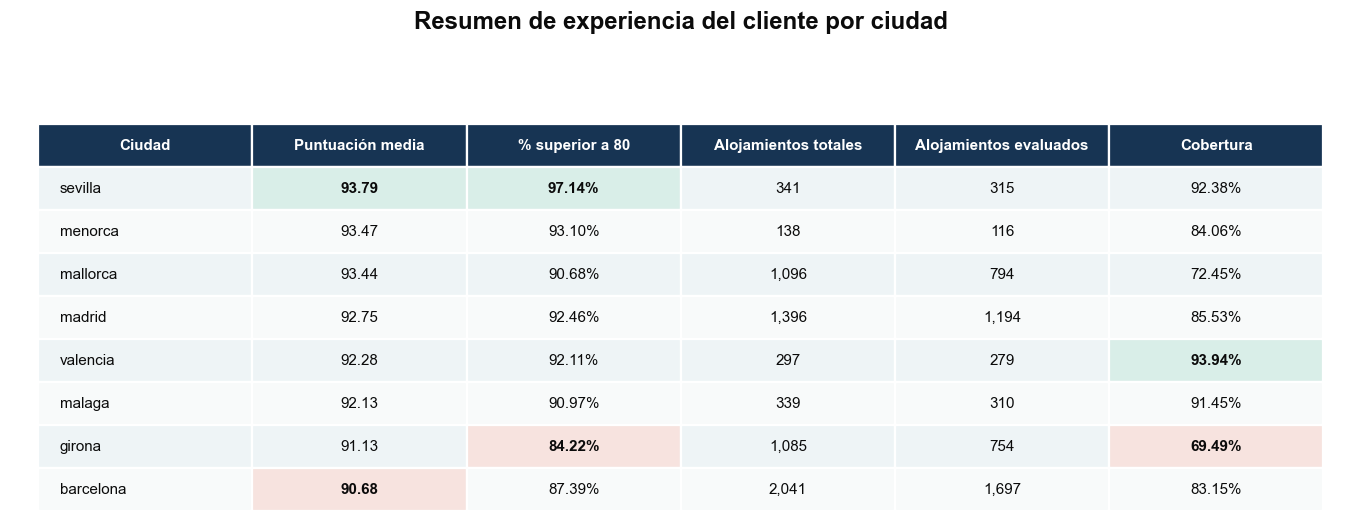

In [7]:
tabla_resumen = resumen_ciudad.rename(columns={
    "city": "Ciudad",
    "average_rating": "Puntuación media",
    "percentage_over_80": "% superior a 80",
    "total_accommodations": "Alojamientos totales",
    "rated_accommodations": "Alojamientos evaluados",
    "rating_coverage_pct": "Cobertura",
})

tabla_grafica(
    tabla_resumen,
    "Resumen de experiencia del cliente por ciudad",
    formatos={
        "Puntuación media": "{:.2f}",
        "% superior a 80": "{:.2f}%",
        "Alojamientos totales": "{:,.0f}",
        "Alojamientos evaluados": "{:,.0f}",
        "Cobertura": "{:.2f}%",
    },
    destacar_max=["Puntuación media", "% superior a 80", "Cobertura"],
    destacar_min=["Puntuación media", "% superior a 80", "Cobertura"],
    ancho=12,
)


## 6. Resumen visual de KPI

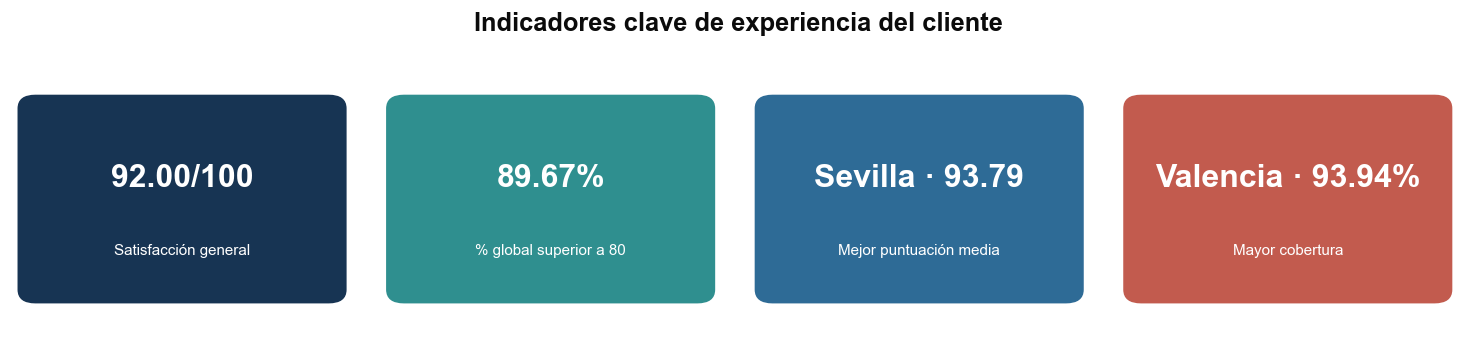

In [8]:
mejor_rating = resumen_ciudad.iloc[0]
mejor_porcentaje = resumen_ciudad.loc[
    resumen_ciudad["percentage_over_80"].idxmax()
]
mejor_cobertura = resumen_ciudad.loc[
    resumen_ciudad["rating_coverage_pct"].idxmax()
]

tarjetas_kpi(
    [
        ("Satisfacción general", f"{indice_satisfaccion_general:.2f}/100", NAVY),
        ("% global superior a 80", f"{porcentaje_global_superior_80:.2f}%", TEAL),
        (
            "Mejor puntuación media",
            f"{mejor_rating['city'].title()} · {mejor_rating['average_rating']:.2f}",
            ACERO,
        ),
        (
            "Mayor cobertura",
            f"{mejor_cobertura['city'].title()} · {mejor_cobertura['rating_coverage_pct']:.2f}%",
            TERRACOTA,
        ),
    ],
    "Indicadores clave de experiencia del cliente",
)


## 7. Visualizaciones principales

Primero se compara la puntuación media entre ciudades. Después se incorpora un **box plot** para observar la distribución, la mediana y la variabilidad que quedan ocultas detrás de la media.

Los gráficos de barras comienzan cerca del rango observado para facilitar la comparación. Por ello, el eje está deliberadamente ampliado y no representa una escala completa desde cero.


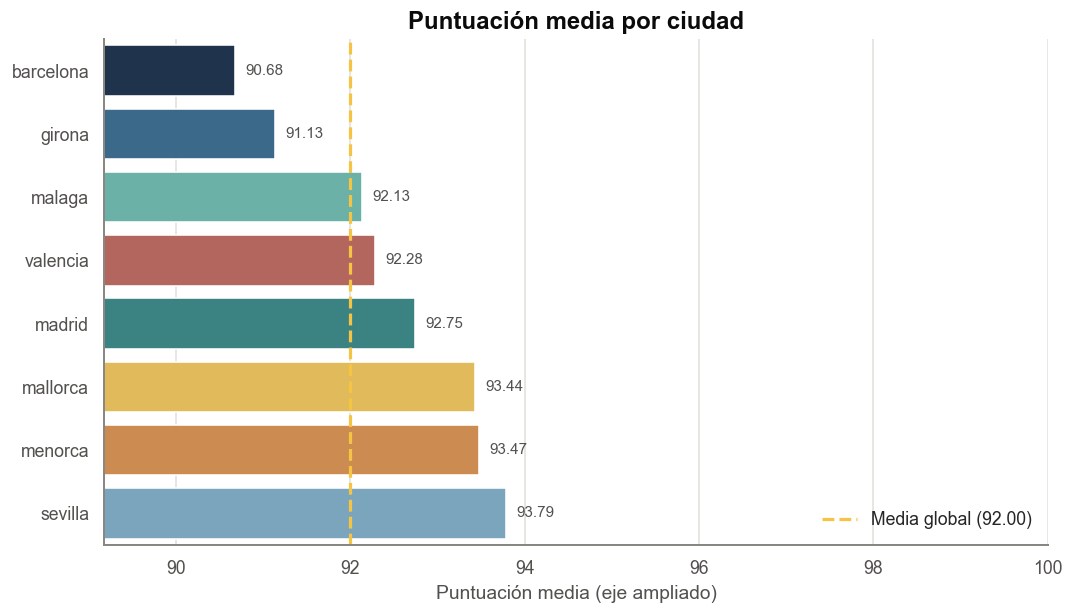

In [9]:
orden_rating = resumen_ciudad.sort_values("average_rating")
colores = [color_ciudad(ciudad) for ciudad in orden_rating["city"]]

fig, ax = plt.subplots(figsize=(9.5, 5.5))
sns.barplot(
    data=orden_rating, x="average_rating", y="city",
    hue="city", palette=COLOR_CIUDAD, legend=False, ax=ax
)

ax.axvline(
    indice_satisfaccion_general, color=AMARILLO,
    linestyle="--", linewidth=2,
    label=f"Media global ({indice_satisfaccion_general:.2f})"
)
ax.set(
    title="Puntuación media por ciudad",
    xlabel="Puntuación media (eje ampliado)",
    ylabel="",
    xlim=(orden_rating["average_rating"].min() - 1.5, 100),
)
ax.legend(frameon=False, loc="lower right")
etiquetas_barras(ax, desplazamiento=0.12)

plt.tight_layout()
plt.show()


### Distribución de la puntuación general por ciudad

El box plot complementa el gráfico de medias y permite comprobar si las diferencias entre ciudades se deben a un desplazamiento general de la distribución o a valores extremos.

Los valores atípicos se muestran con un tamaño reducido para conservar información sin recargar el gráfico.


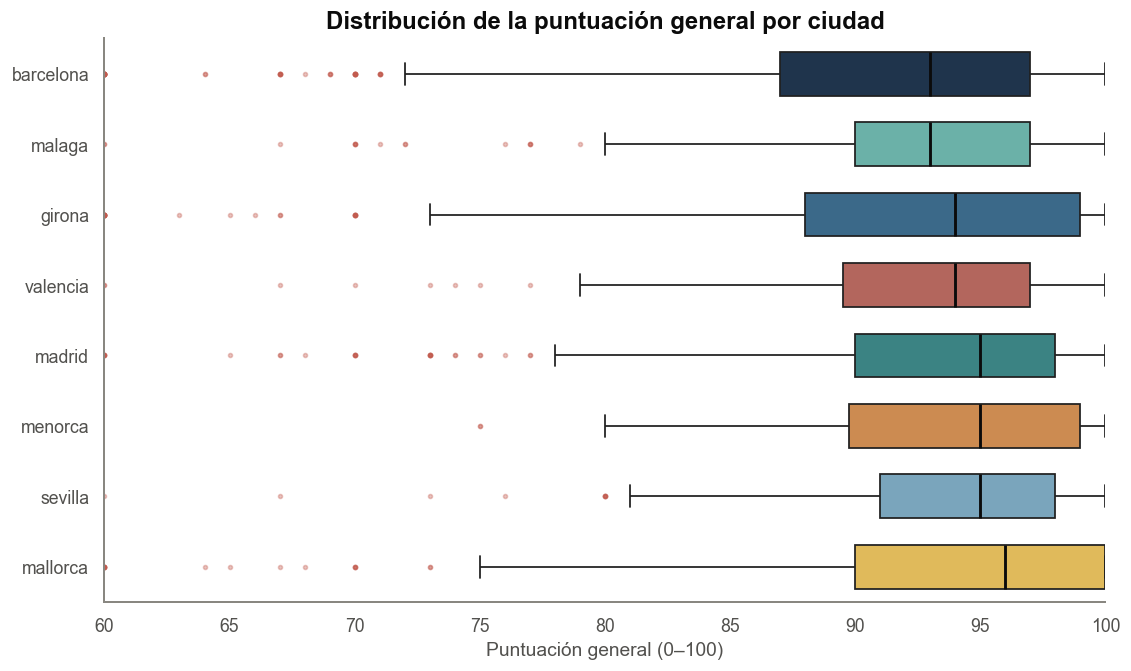

In [10]:
orden_boxplot = (
    df_customer.groupby("city")["review_scores_rating"]
    .median()
    .sort_values()
    .index
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df_customer,
    x="review_scores_rating",
    y="city",
    order=orden_boxplot,
    hue="city",
    palette=COLOR_CIUDAD,
    legend=False,
    width=0.62,
    linewidth=1.1,
    flierprops={
        "marker": "o",
        "markersize": 2.5,
        "markerfacecolor": TERRACOTA,
        "markeredgecolor": TERRACOTA,
        "alpha": 0.35,
    },
    medianprops={"color": TINTA, "linewidth": 1.8},
    ax=ax,
)

ax.set(
    title="Distribución de la puntuación general por ciudad",
    xlabel="Puntuación general (0–100)",
    ylabel="",
    xlim=(60, 100),
)
ax.grid(axis="x")
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()


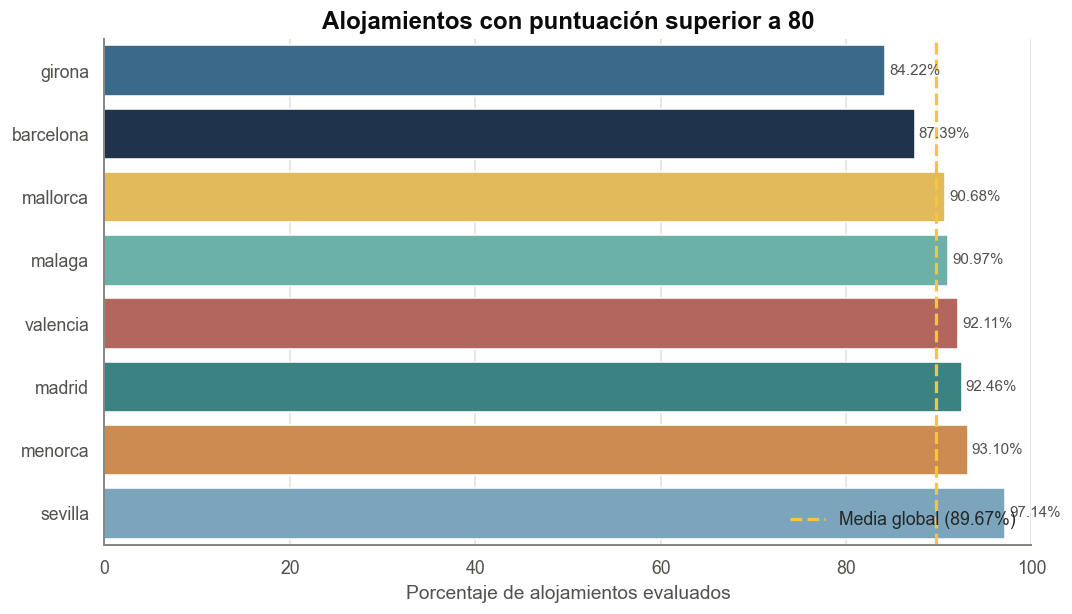

In [11]:
orden_80 = resumen_ciudad.sort_values("percentage_over_80")

fig, ax = plt.subplots(figsize=(9.5, 5.5))
sns.barplot(
    data=orden_80, x="percentage_over_80", y="city",
    hue="city", palette=COLOR_CIUDAD, legend=False, ax=ax
)

ax.axvline(
    porcentaje_global_superior_80, color=AMARILLO,
    linestyle="--", linewidth=2,
    label=f"Media global ({porcentaje_global_superior_80:.2f}%)"
)
ax.set(
    title="Alojamientos con puntuación superior a 80",
    xlabel="Porcentaje de alojamientos evaluados",
    ylabel="",
    xlim=(0, 100),
)
ax.legend(frameon=False, loc="lower right")
etiquetas_barras(ax, sufijo="%", desplazamiento=0.45)

plt.tight_layout()
plt.show()


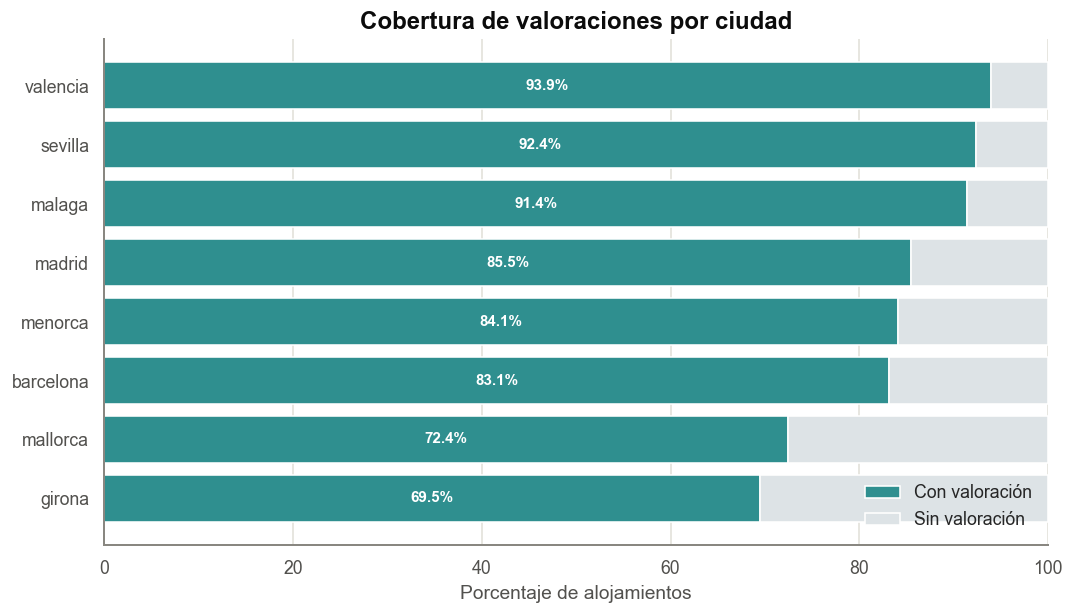

In [12]:
cobertura = resumen_ciudad.sort_values("rating_coverage_pct").copy()
cobertura["sin_valoracion_pct"] = 100 - cobertura["rating_coverage_pct"]

fig, ax = plt.subplots(figsize=(9.5, 5.5))
ax.barh(
    cobertura["city"], cobertura["rating_coverage_pct"],
    color=TEAL, label="Con valoración"
)
ax.barh(
    cobertura["city"], cobertura["sin_valoracion_pct"],
    left=cobertura["rating_coverage_pct"],
    color="#DDE3E6", label="Sin valoración"
)

for posicion, valor in enumerate(cobertura["rating_coverage_pct"]):
    ax.text(
        valor / 2, posicion, f"{valor:.1f}%",
        ha="center", va="center", color=BLANCO,
        fontsize=9.5, fontweight="bold",
    )

ax.set(
    title="Cobertura de valoraciones por ciudad",
    xlabel="Porcentaje de alojamientos",
    ylabel="",
    xlim=(0, 100),
)
ax.legend(frameon=False, loc="lower right")

plt.tight_layout()
plt.show()


## 8. Análisis complementario — KPI 4

Se comparan los componentes de satisfacción en escala 0–10 para identificar la dimensión mejor valorada y la principal oportunidad de mejora.


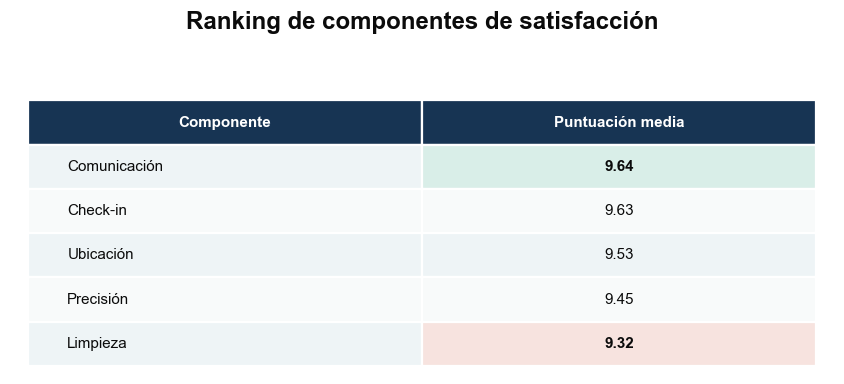

In [13]:
resumen_componentes = (
    df[columnas_satisfaccion]
    .mean()
    .rename_axis("variable")
    .reset_index(name="Puntuación media")
)

nombres_componentes = {
    "review_scores_accuracy": "Precisión",
    "review_scores_cleanliness": "Limpieza",
    "review_scores_checkin": "Check-in",
    "review_scores_communication": "Comunicación",
    "review_scores_location": "Ubicación",
}

resumen_componentes["Componente"] = resumen_componentes["variable"].map(
    nombres_componentes
)

resumen_componentes = (
    resumen_componentes[["Componente", "Puntuación media"]]
    .sort_values("Puntuación media", ascending=False)
    .reset_index(drop=True)
)

tabla_grafica(
    resumen_componentes,
    "Ranking de componentes de satisfacción",
    formatos={"Puntuación media": "{:.2f}"},
    destacar_max=["Puntuación media"],
    destacar_min=["Puntuación media"],
    ancho=7.5,
)


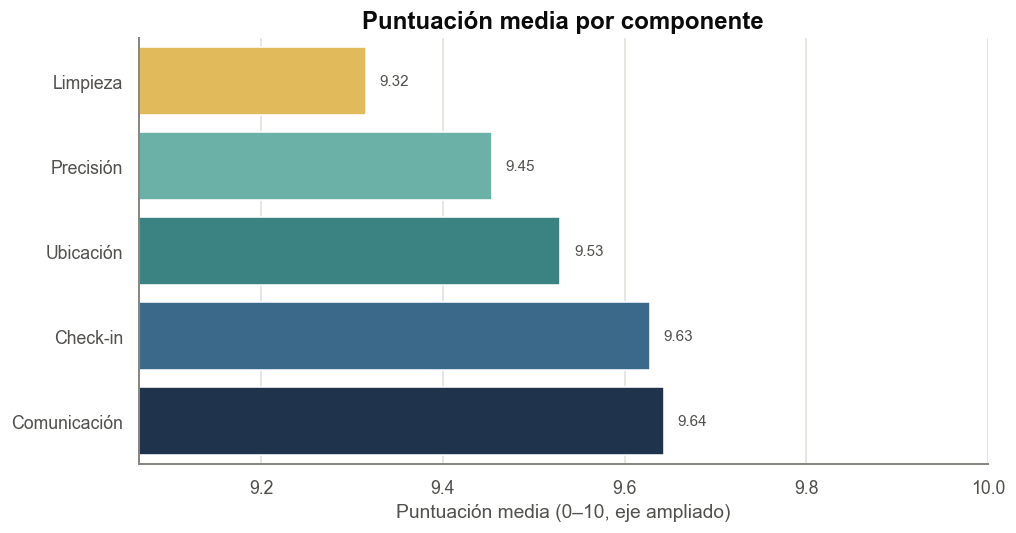

In [14]:
componentes_ordenados = resumen_componentes.sort_values("Puntuación media")
paleta_componentes = [AMARILLO, AQUA, TEAL, ACERO, NAVY]

fig, ax = plt.subplots(figsize=(9, 4.8))
sns.barplot(
    data=componentes_ordenados,
    x="Puntuación media",
    y="Componente",
    hue="Componente",
    palette=paleta_componentes,
    legend=False,
    ax=ax,
)

ax.set(
    title="Puntuación media por componente",
    xlabel="Puntuación media (0–10, eje ampliado)",
    ylabel="",
    xlim=(componentes_ordenados["Puntuación media"].min() - 0.25, 10),
)
etiquetas_barras(ax, desplazamiento=0.015)

plt.tight_layout()
plt.show()


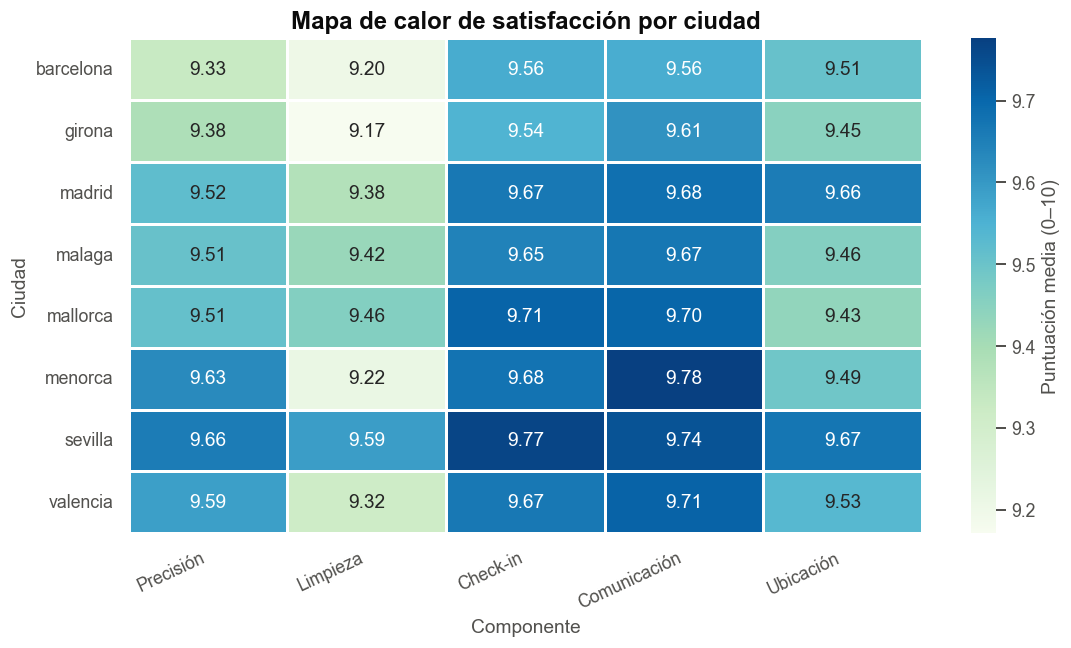

In [15]:
satisfaccion_ciudad = (
    df.groupby("city")[columnas_satisfaccion]
    .mean()
    .rename(columns=nombres_componentes)
)

fig, ax = plt.subplots(figsize=(10, 5.8))
sns.heatmap(
    satisfaccion_ciudad,
    annot=True,
    fmt=".2f",
    cmap="GnBu",
    linewidths=0.8,
    linecolor=BLANCO,
    cbar_kws={"label": "Puntuación media (0–10)"},
    ax=ax,
)

ax.set(
    title="Mapa de calor de satisfacción por ciudad",
    xlabel="Componente",
    ylabel="Ciudad",
)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


## 9. Comprobación estadística

La comparación visual se complementa con:

- **Kruskal–Wallis** para comprobar si la distribución de la puntuación general cambia entre ciudades;
- **Chi-cuadrado** para comprobar si la proporción de alojamientos con puntuación superior a 80 depende de la ciudad.

Estas pruebas identifican asociación o diferencias, pero no explican causalidad.


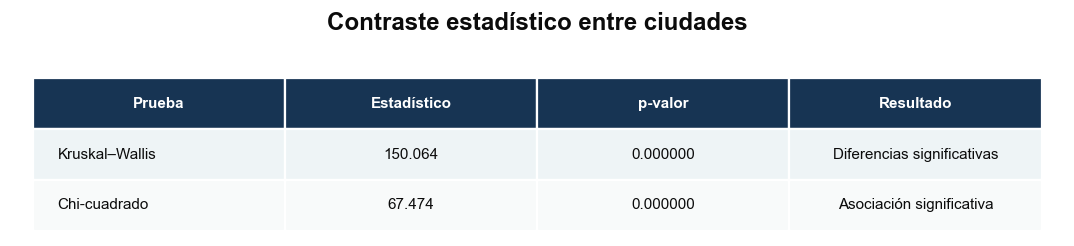

Cramér's V para ciudad × rating_above_80: 0.111


In [16]:
grupos_rating = [
    grupo["review_scores_rating"].dropna().values
    for _, grupo in df_customer.groupby("city")
]

h_stat, p_kruskal = kruskal(*grupos_rating)

tabla_contingencia = pd.crosstab(
    df_customer["city"], df_customer["rating_above_80"]
)
chi2, p_chi2, grados_libertad, _ = chi2_contingency(tabla_contingencia)

n_total = tabla_contingencia.to_numpy().sum()
cramers_v = np.sqrt(
    chi2 / (n_total * min(tabla_contingencia.shape[0] - 1, 1))
)

resultados_tests = pd.DataFrame({
    "Prueba": ["Kruskal–Wallis", "Chi-cuadrado"],
    "Estadístico": [h_stat, chi2],
    "p-valor": [p_kruskal, p_chi2],
    "Resultado": [
        "Diferencias significativas" if p_kruskal < 0.05 else "No significativas",
        "Asociación significativa" if p_chi2 < 0.05 else "No significativa",
    ],
})

tabla_grafica(
    resultados_tests,
    "Contraste estadístico entre ciudades",
    formatos={"Estadístico": "{:.3f}", "p-valor": "{:.6f}"},
    ancho=9.5,
)

print(f"Cramér's V para ciudad × rating_above_80: {cramers_v:.3f}")


## 10. Resultados principales

In [17]:
peor_rating = resumen_ciudad.iloc[-1]
menor_cobertura = resumen_ciudad.loc[
    resumen_ciudad["rating_coverage_pct"].idxmin()
]
mejor_componente = resumen_componentes.iloc[0]
peor_componente = resumen_componentes.iloc[-1]

print(
    f"• La satisfacción general es {indice_satisfaccion_general:.2f}/100."
)
print(
    f"• {porcentaje_global_superior_80:.2f}% de los alojamientos evaluados "
    "supera una puntuación de 80."
)
print(
    f"• {mejor_rating['city'].title()} presenta la puntuación media más alta "
    f"({mejor_rating['average_rating']:.2f}), mientras que "
    f"{peor_rating['city'].title()} registra la más baja "
    f"({peor_rating['average_rating']:.2f})."
)
print(
    f"• La cobertura más baja corresponde a "
    f"{menor_cobertura['city'].title()} "
    f"({menor_cobertura['rating_coverage_pct']:.2f}%)."
)
print(
    f"• El componente mejor valorado es {mejor_componente['Componente']} "
    f"({mejor_componente['Puntuación media']:.2f}/10) y el más bajo es "
    f"{peor_componente['Componente']} "
    f"({peor_componente['Puntuación media']:.2f}/10)."
)


• La satisfacción general es 92.00/100.
• 89.67% de los alojamientos evaluados supera una puntuación de 80.
• Sevilla presenta la puntuación media más alta (93.79), mientras que Barcelona registra la más baja (90.68).
• La cobertura más baja corresponde a Girona (69.49%).
• El componente mejor valorado es Comunicación (9.64/10) y el más bajo es Limpieza (9.32/10).


## 11. Conclusiones y recomendaciones

1. **La satisfacción general es alta**, pero existen diferencias moderadas entre ciudades. El ranking debe interpretarse junto con la cobertura y el tamaño de muestra.
2. **Sevilla destaca en valoración media**, mientras que Barcelona presenta una media inferior al resto del grupo analizado.
3. **Girona necesita especial atención en cobertura**, porque una proporción relevante de alojamientos no dispone de valoración válida.
4. **Comunicación y check-in son fortalezas**, mientras que limpieza representa la principal oportunidad de mejora.
5. Las pruebas estadísticas permiten afirmar si existen diferencias entre ciudades, pero no demuestran que la ciudad sea la causa. Para explicar los resultados convendría incorporar variables como tipo de alojamiento, precio, antigüedad y volumen de reseñas.

### Recomendaciones de negocio

- reforzar protocolos de limpieza y auditorías de calidad;
- incentivar nuevas valoraciones en ciudades con menor cobertura;
- analizar por separado alojamientos con pocas reseñas;
- replicar prácticas de comunicación y check-in de las ciudades mejor posicionadas.
